In [1]:
# CELL 1: Imports & basic setup

import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# CELL 2: Mount Google Drive & define paths

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/mbti-tune")
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

MBTI_PLAYLIST_DIR = RAW_DIR / "mbti_playlists"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MBTI_PLAYLIST_DIR:", MBTI_PLAYLIST_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/mbti-tune
MBTI_PLAYLIST_DIR: /content/drive/MyDrive/mbti-tune/data/raw/mbti_playlists


In [3]:
# CELL 3: Load aggregated MBTI playlist stats (16 CSV files)

csv_files = sorted(glob.glob(str(MBTI_PLAYLIST_DIR / "*.csv")))
print("Found aggregated MBTI files:", len(csv_files))

agg_rows = []
for f in csv_files:
    df = pd.read_csv(f)
    agg_rows.append(df)

agg_df = pd.concat(agg_rows, ignore_index=True)
print("Aggregated MBTI stats shape:", agg_df.shape)
print(agg_df.head())

assert "mbti" in agg_df.columns, "Expected 'mbti' column in aggregated MBTI files"


Found aggregated MBTI files: 16
Aggregated MBTI stats shape: (4201, 49)
   mbti function_pair                                 playlist_name  \
0  ENFJ            NF                                        Enfj 😇   
1  ENFJ            NF                      enfj // the protagonist    
2  ENFJ            NF  enfj songs according to personality database   
3  ENFJ            NF                                  ENFJ vibes‼️   
4  ENFJ            NF                                        [ENFJ]   

              playlist_id  track_count  danceability_mean  danceability_stdev  \
0  4AE4DBt4YjJJ8v4Hk9myWl           41           0.580512            0.124325   
1  6th4JW4Dky7UjeEhHuQeQd           38           0.550947            0.156753   
2  4g2AYw35pR37u2QpwpSryq           50           0.564680            0.116814   
3  1eVgLeDoHD123LB6VldjGY           50           0.535200            0.122586   
4  49BWXniDb2gtfI1e4Z3ILr           50           0.526700            0.123802   

   energy_mean

In [4]:
# CELL 4: Data Cleaning — handle NaN, inf, scaling

# Select numeric columns only
numeric_cols = agg_df.select_dtypes(include=[np.number]).columns
print("Numeric feature columns:", len(numeric_cols))

X_raw = agg_df[numeric_cols].values.astype(np.float32)
y_raw = agg_df["mbti"].astype(str)

# 1. Replace NaN, inf, -inf
X_clean = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

# 2. Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X_clean).astype(np.float32)

# Encode MBTI labels
unique_types = sorted(y_raw.unique())
type_to_idx = {t: i for i, t in enumerate(unique_types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}

y = y_raw.map(type_to_idx).values.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique MBTI types:", unique_types)


Numeric feature columns: 45
X shape: (4201, 45)
y shape: (4201,)
Unique MBTI types: ['ENFJ', 'ENFP', 'ENTJ', 'ENTP', 'ESFJ', 'ESFP', 'ESTJ', 'ESTP', 'INFJ', 'INFP', 'INTJ', 'INTP', 'ISFJ', 'ISFP', 'ISTJ', 'ISTP']


In [5]:
# CELL 5: Stratified Train/Val/Test Split + DataLoaders

from sklearn.model_selection import train_test_split

# 70% train, 15% val, 15% test — stratified by MBTI type
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Split sizes:")
print("  Train:", X_train.shape[0])
print("  Val:  ", X_val.shape[0])
print("  Test: ", X_test.shape[0])

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Define MBTIDataset class
class MBTIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# DataLoaders
batch_size = 8

train_loader = DataLoader(
    MBTIDataset(X_train, y_train), batch_size=batch_size, shuffle=True, drop_last=False
)

val_loader = DataLoader(
    MBTIDataset(X_val, y_val), batch_size=batch_size, shuffle=False, drop_last=False
)

test_loader = DataLoader(
    MBTIDataset(X_test, y_test), batch_size=batch_size, shuffle=False, drop_last=False
)

Split sizes:
  Train: 2940
  Val:   630
  Test:  631


In [6]:
# CELL 6: Define neural MBTI classifier (no BatchNorm)

class MBTIClassifierV3(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X.shape[1]
num_classes = len(unique_types)

model = MBTIClassifierV3(input_dim=input_dim, hidden_dim=128, num_classes=num_classes).to(device)
print(model)


MBTIClassifierV3(
  (net): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=16, bias=True)
  )
)


In [7]:
# CELL 7: Training setup

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

num_epochs = 200

print("num_epochs:", num_epochs)
print("input_dim:", input_dim)
print("num_classes:", num_classes)


num_epochs: 200
input_dim: 45
num_classes: 16


In [8]:
# CELL 8: Train classifier with validation monitoring

best_val_loss = float("inf")
best_state = None

for epoch in range(1, num_epochs + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)

    # ----- VALIDATION -----
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_losses.append(loss.item())

    val_loss = np.mean(val_losses)

    # Track best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

model.load_state_dict(best_state)
print("\n✅ Training finished. Best validation loss:", best_val_loss)


Epoch 001 | train_loss=2.7500 | val_loss=2.7169
Epoch 020 | train_loss=2.2141 | val_loss=2.2471
Epoch 040 | train_loss=2.0822 | val_loss=2.2367
Epoch 060 | train_loss=1.9830 | val_loss=2.2446
Epoch 080 | train_loss=1.8874 | val_loss=2.2610
Epoch 100 | train_loss=1.8264 | val_loss=2.2799
Epoch 120 | train_loss=1.7632 | val_loss=2.3020
Epoch 140 | train_loss=1.6664 | val_loss=2.3334
Epoch 160 | train_loss=1.6173 | val_loss=2.3620
Epoch 180 | train_loss=1.5490 | val_loss=2.3899
Epoch 200 | train_loss=1.5001 | val_loss=2.4234

✅ Training finished. Best validation loss: 2.2345937731899794


Overall Test Accuracy: 0.3059
Global MAE (Probs): 0.0984


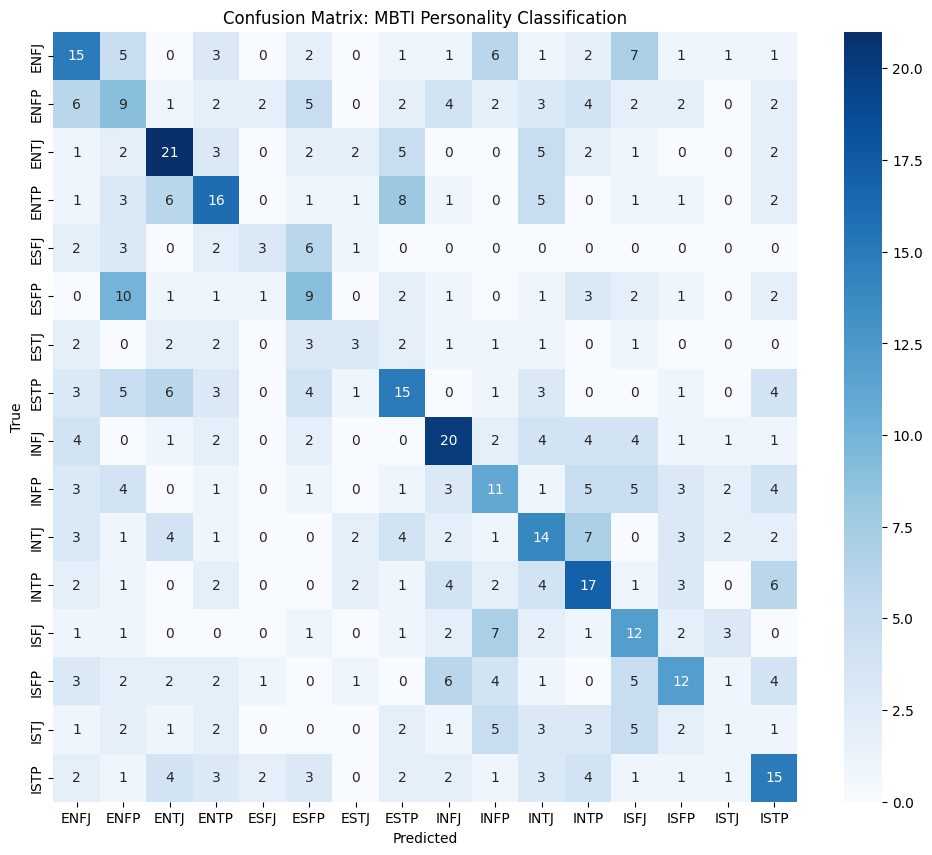


Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.31      0.33      0.32        46
        ENFP       0.18      0.20      0.19        46
        ENTJ       0.43      0.46      0.44        46
        ENTP       0.36      0.35      0.35        46
        ESFJ       0.33      0.18      0.23        17
        ESFP       0.23      0.26      0.25        34
        ESTJ       0.23      0.17      0.19        18
        ESTP       0.33      0.33      0.33        46
        INFJ       0.42      0.43      0.43        46
        INFP       0.26      0.25      0.25        44
        INTJ       0.27      0.30      0.29        46
        INTP       0.33      0.38      0.35        45
        ISFJ       0.26      0.36      0.30        33
        ISFP       0.36      0.27      0.31        44
        ISTJ       0.08      0.03      0.05        29
        ISTP       0.33      0.33      0.33        45

    accuracy                           0.31       631
  

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, mean_absolute_error
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    logits = model(X_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = np.argmax(probs, axis=1)

test_acc = accuracy_score(y_test, preds)

# Calculate Global MAE
y_test_one_hot = F.one_hot(torch.tensor(y_test, dtype=torch.long), num_classes=num_classes).numpy()
global_mae = mean_absolute_error(y_test_one_hot, probs)

print(f"Overall Test Accuracy: {test_acc:.4f}")
print(f"Global MAE (Probs): {global_mae:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_types, yticklabels=unique_types)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: MBTI Personality Classification')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=unique_types))

In [10]:
# CELL 10: Dynamic Dominant Letter Predictions
print("Letter-Specific MBTI Predictions (Axis Dominance):\n")

indices_E = [i for i, t in idx_to_type.items() if t[0] == "E"]
indices_I = [i for i, t in idx_to_type.items() if t[0] == "I"]
indices_S = [i for i, t in idx_to_type.items() if t[1] == "S"]
indices_N = [i for i, t in idx_to_type.items() if t[1] == "N"]
indices_T = [i for i, t in idx_to_type.items() if t[2] == "T"]
indices_F = [i for i, t in idx_to_type.items() if t[2] == "F"]
indices_J = [i for i, t in idx_to_type.items() if t[3] == "J"]
indices_P = [i for i, t in idx_to_type.items() if t[3] == "P"]

def letter_probs(prob_vec):
    return {
        "E": float(prob_vec[indices_E].sum()),
        "I": float(prob_vec[indices_I].sum()),
        "S": float(prob_vec[indices_S].sum()),
        "N": float(prob_vec[indices_N].sum()),
        "T": float(prob_vec[indices_T].sum()),
        "F": float(prob_vec[indices_F].sum()),
        "J": float(prob_vec[indices_J].sum()),
        "P": float(prob_vec[indices_P].sum())
    }

for i in range(len(y_test)):
    true_type = idx_to_type[y_test[i]]
    prob_vec = probs[i]
    lp = letter_probs(prob_vec)

    # Determine dominant letter and its specific percentage for each axis
    E_vs_I = ("E", lp["E"]) if lp["E"] >= lp["I"] else ("I", lp["I"])
    S_vs_N = ("S", lp["S"]) if lp["S"] >= lp["N"] else ("N", lp["N"])
    T_vs_F = ("T", lp["T"]) if lp["T"] >= lp["F"] else ("F", lp["F"])
    J_vs_P = ("J", lp["J"]) if lp["J"] >= lp["P"] else ("P", lp["P"])

    final_mbti = E_vs_I[0] + S_vs_N[0] + T_vs_F[0] + J_vs_P[0]

    print(f"Sample {i}:")
    print(f"  True Label: {true_type}")
    print(f"  Result: {final_mbti}")
    print(f"    {E_vs_I[0]}: {E_vs_I[1]*100:.1f}%")
    print(f"    {S_vs_N[0]}: {S_vs_N[1]*100:.1f}%")
    print(f"    {T_vs_F[0]}: {T_vs_F[1]*100:.1f}%")
    print(f"    {J_vs_P[0]}: {J_vs_P[1]*100:.1f}%\n")

Letter-Specific MBTI Predictions (Axis Dominance):

Sample 0:
  True Label: ENFJ
  Result: ENFJ
    E: 76.5%
    N: 72.3%
    F: 81.4%
    J: 87.4%

Sample 1:
  True Label: INTP
  Result: ENFJ
    E: 56.7%
    N: 61.9%
    F: 71.2%
    J: 58.9%

Sample 2:
  True Label: INFJ
  Result: INTJ
    I: 78.6%
    N: 66.5%
    T: 80.2%
    J: 61.3%

Sample 3:
  True Label: ENFJ
  Result: INFP
    I: 87.3%
    N: 70.0%
    F: 84.2%
    P: 55.4%

Sample 4:
  True Label: ENFP
  Result: ENFP
    E: 53.6%
    N: 54.1%
    F: 77.8%
    P: 50.2%

Sample 5:
  True Label: INTP
  Result: INTP
    I: 84.0%
    N: 81.1%
    T: 56.5%
    P: 73.9%

Sample 6:
  True Label: ESTP
  Result: ESTP
    E: 93.9%
    S: 75.1%
    T: 73.4%
    P: 82.0%

Sample 7:
  True Label: ENFP
  Result: ENFP
    E: 54.8%
    N: 51.5%
    F: 69.4%
    P: 76.6%

Sample 8:
  True Label: ENTP
  Result: ESTP
    E: 62.0%
    S: 75.4%
    T: 87.2%
    P: 76.8%

Sample 9:
  True Label: ESFJ
  Result: ENFP
    E: 84.3%
    N: 61.2%
    F

  0%|          | 0/50 [00:00<?, ?it/s]

Showing feature importance for: ENFJ


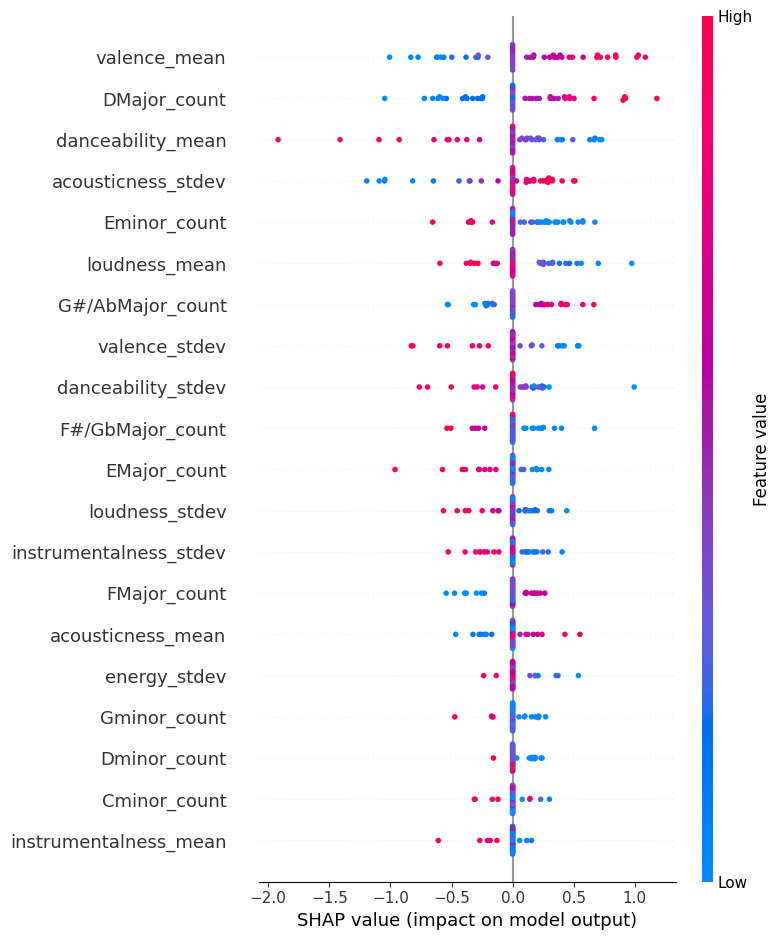

In [11]:
import shap

# We use a summary of the training data as a background distribution
background = torch.tensor(X_train[:100], dtype=torch.float32).to(device)
test_sample = torch.tensor(X_test[:50], dtype=torch.float32).to(device)

# Define a wrapper function for SHAP
def model_predict(data):
    data_t = torch.tensor(data, dtype=torch.float32).to(device)
    return model(data_t).detach().cpu().numpy()

# Initialize Explainer
explainer = shap.KernelExplainer(model_predict, background.cpu().numpy())
shap_values = explainer.shap_values(test_sample.cpu().numpy())

# Plot SHAP summary for the first class (e.g., ENFJ)
print(f"Showing feature importance for: {unique_types[0]}")
shap.summary_plot(shap_values[:, :, 0], test_sample.cpu().numpy(), feature_names=numeric_cols)

In [13]:
# Cell 12: Export Final Model and Feature List
import json

PROCESSED_DIR = DATA_DIR / "processed"

# Save the feature list so the app knows the exact column order
features_list = list(numeric_cols)
with open(PROCESSED_DIR / "mbti_features.json", "w") as f:
    json.dump(features_list, f)

FINAL_MODEL_PATH = PROCESSED_DIR / "mbti_classifier.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'type_to_idx': type_to_idx,
    'idx_to_type': idx_to_type,
    'features': features_list
}, FINAL_MODEL_PATH)

print(f"✅ Exported mbti_features.json and {FINAL_MODEL_PATH.name}")

✅ Exported mbti_features.json and mbti_classifier.pth


In [14]:
# CELL 13: Final Classifier Summary
print("===== FINAL CLASSIFIER SUMMARY =====")
print(f"Total Playlists Analyzed: {len(X)}")
print(f"Input Feature Dimensions: {X.shape[1]}")
print(f"Number of MBTI Classes:   {num_classes}")
print(f"Best Validation Loss:     {best_val_loss:.4f}")
print(f"Overall Test Accuracy:    {test_acc*100:.2f}%")
print(f"Global MAE (Probs):       {global_mae:.4f}")
print("-" * 36)
print(f"✅ Training Split:         70/15/15 (Stratified)")
print(f"✅ Explainability:         SHAP KernelExplainer")
print(f"✅ Model Exported to:      mbti_classifier.pth")
print("====================================")

===== FINAL CLASSIFIER SUMMARY =====
Total Playlists Analyzed: 4201
Input Feature Dimensions: 45
Number of MBTI Classes:   16
Best Validation Loss:     2.2346
Overall Test Accuracy:    30.59%
Global MAE (Probs):       0.0984
------------------------------------
✅ Training Split:         70/15/15 (Stratified)
✅ Explainability:         SHAP KernelExplainer
✅ Model Exported to:      mbti_classifier.pth


In [15]:
# CELL: Save the 45-feature scaler (ADD THIS!)
import joblib
scaler_45_path = PROCESSED_DIR / "mbti_scaler.pkl"
joblib.dump(scaler, scaler_45_path)
print(f"✅ Saved 45-feature scaler to {scaler_45_path}")

# CELL: Save idx_to_type as JSON
with open(PROCESSED_DIR / "idx_to_type.json", "w") as f:
    json.dump(idx_to_type, f)
print(f"✅ Saved idx_to_type to {PROCESSED_DIR / 'idx_to_type.json'}")

# CELL: Verify all files exist
print("\n===== VERIFYING EXPORTED FILES =====")
files_to_check = [
    "mbti_classifier.pth",
    "mbti_scaler.pkl",
    "mbti_features.json",
    "idx_to_type.json"
]
for f in files_to_check:
    path = PROCESSED_DIR / f
    if path.exists():
        print(f"✅ {f} - {path.stat().st_size} bytes")
    else:
        print(f"❌ {f} - MISSING!")

✅ Saved 45-feature scaler to /content/drive/MyDrive/mbti-tune/data/processed/mbti_scaler.pkl
✅ Saved idx_to_type to /content/drive/MyDrive/mbti-tune/data/processed/idx_to_type.json

===== VERIFYING EXPORTED FILES =====
✅ mbti_classifier.pth - 102453 bytes
✅ mbti_scaler.pkl - 1679 bytes
✅ mbti_features.json - 807 bytes
✅ idx_to_type.json - 214 bytes
